# Iteración 3: Algoritmos de Clasificación sobre Juegos Top Positivos de Steam

En este notebook aplicaremos algoritmos de clasificación sobre el dataset `data_top_positives.csv`. Nuestro objetivo será predecir si un juego excelentemente calificado logrará la máxima distinción de reseñas: **"Overwhelmingly Positive" (Extremadamente Positivo)** frente a **"Very Positive" (Muy Positivo)**, utilizando características del juego como su precio, tiempo de juego, géneros y etiquetas de Steam.

## Objetivos del Notebook:
1. **Cargar y Explorar el Dataset:** Entender la estructura y balance de las clases.
2. **Preprocesamiento:** Limpieza de datos, codificación de variables y división en conjuntos de entrenamiento/prueba.
3. **Modelado Base:** Entrenar un modelo de **Random Forest (Bosque Aleatorio)** con ajuste para clases desbalanceadas.
4. **Evaluación de Modelos:** Medir el desempeño usando métricas adecuadas (F1-score, Precision-Recall AUC) y analizar la importancia de las características (Feature Importance).


In [1]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-Learn para preprocesamiento y partición
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Scikit-Learn para modelos y métricas
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    precision_recall_curve, 
    auc, 
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Configuración de los gráficos
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)
print("¡Librerías importadas correctamente!")


¡Librerías importadas correctamente!


In [2]:
# ==============================================================================
# 2. CARGA DEL DATASET
# ==============================================================================

# Si estás en Google Colab y subiste el archivo directamente a la barra lateral:
file_path_colab = 'data_top_positives.csv'

# Ruta local en tu espacio de trabajo actual:
file_path_local = 'Iteracion 3/code/data_top_positives.csv'

if os.path.exists(file_path_colab):
    path = file_path_colab
    print(f"Cargando dataset desde Colab: {path}")
elif os.path.exists(file_path_local):
    path = file_path_local
    print(f"Cargando dataset localmente: {path}")
else:
    # Si no lo encuentra, te permite subirlo en Colab
    print("Dataset no encontrado en las rutas automáticas.")
    try:
        from google.colab import files
        print("Por favor, sube el archivo 'data_top_positives.csv':")
        uploaded = files.upload()
        path = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError("No se encontró el archivo en la ruta local ni en Colab.")

# Leer el archivo CSV
df = pd.read_csv(path)
print(f"\n¡Dataset cargado exitosamente!")
print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas.")


Cargando dataset desde Colab: data_top_positives.csv

¡Dataset cargado exitosamente!
Dimensiones del dataset: 21390 filas, 131 columnas.


# 3. Exploración y Preparación de la Variable Objetivo (`review_score_cat`)

Nuestra variable objetivo es `review_score_cat`. Vamos a analizar cómo se distribuye y a codificarla de la siguiente manera:
*   **Clase 0:** `Very Positive` (Muy Positivo) - La clase mayoritaria.
*   **Clase 1:** `Overwhelmingly Positive` (Extremadamente Positivo) - La clase minoritaria y la que queremos predecir/detectar (nuestro "éxito" élite).


Distribución original de review_score_cat:
review_score_cat
Very Positive              20124
Overwhelmingly Positive     1266
Name: count, dtype: int64
--------------------------------------------------
Distribución después del mapeo (target):
target
0    20124
1     1266
Name: count, dtype: int64
--------------------------------------------------
Porcentaje de juegos 'Very Positive' (Clase 0): 94.08%
Porcentaje de juegos 'Overwhelmingly Positive' (Clase 1): 5.92%


C:\Users\dafem\AppData\Local\Temp\ipykernel_22840\2288769871.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = df[target_col].map(mapping)


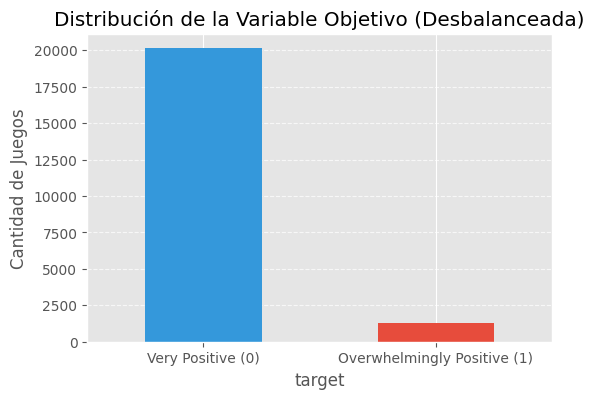

In [3]:
# ==============================================================================
# 3.1. ANALIZAR EL DESBALANCE Y MAPEO DE LA VARIABLE OBJETIVO
# ==============================================================================

# Ver la distribución inicial en texto
target_col = 'review_score_cat'
print("Distribución original de review_score_cat:")
print(df[target_col].value_counts(dropna=False))
print("-" * 50)

# Mapear las categorías a valores numéricos (0 y 1)
# 0 = Very Positive, 1 = Overwhelmingly Positive
mapping = {
    'Very Positive': 0,
    'Overwhelmingly Positive': 1
}

# Creamos una nueva columna 'target'
df['target'] = df[target_col].map(mapping)

# Verificar el resultado del mapeo
print("Distribución después del mapeo (target):")
print(df['target'].value_counts(dropna=False))
print("-" * 50)

# Calcular el porcentaje de desbalance
percentages = df['target'].value_counts(normalize=True) * 100
print(f"Porcentaje de juegos 'Very Positive' (Clase 0): {percentages[0]:.2f}%")
print(f"Porcentaje de juegos 'Overwhelmingly Positive' (Clase 1): {percentages[1]:.2f}%")

# Gráfico de barras simple para ilustrar el desbalance
plt.figure(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.xticks([0, 1], ['Very Positive (0)', 'Overwhelmingly Positive (1)'], rotation=0)
plt.title('Distribución de la Variable Objetivo (Desbalanceada)')
plt.ylabel('Cantidad de Juegos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# 4. Selección de Características (Features) y Limpieza de Datos

Para entrenar nuestro clasificador, dividiremos las variables del dataset en tres grupos:
1. **Características de Entrada ($X$):** Las variables que usará el modelo para predecir.
   * **Numéricas limpias:** `Price`, `Discount`, `DLC count`, `Achievements`, `Average playtime forever`, `Peak CCU`, `Release_year`, `Release_month`.
   * **Binarias (One-Hot Encoded):** Todas las columnas que empiezan con `genre_` (Géneros) y `tag_` (Etiquetas de Steam).
2. **Variables de Fuga de Datos (A eliminar):** `Positive`, `Negative`, `total_reviews`, `review_rate`, `review_score_cat`. Las eliminamos porque definen directamente la clase y harían que el modelo hiciera "trampa".
3. **Metadatos e Identificadores (A eliminar):** IDs, nombres, textos largos (`Name`, `About the game`, `appID`, `Developers`, `Publishers`, etc.) y otras variables categóricas redundantes (como `sales_cat` o `ccu_cat` que son otras variables objetivo).


In [4]:
# ==============================================================================
# 4.1. SELECCIÓN DE COLUMNAS PARA EL MODELO
# ==============================================================================

# Identificar todas las columnas que son de géneros o tags
genre_cols = [col for col in df.columns if col.startswith('genre_')]
tag_cols = [col for col in df.columns if col.startswith('tag_')]

# Definir las variables numéricas que sí queremos usar como características
numeric_features = [
    'Price', 
    'Discount', 
    'DLC count', 
    'Achievements', 
    'Average playtime forever', 
    'Average playtime two weeks',
    'Median playtime forever',
    'Median playtime two weeks',
    'Peak CCU',
    'Release_year',
    'Release_month'
]

# Unir todas las características seleccionadas para X
features_to_use = numeric_features + genre_cols + tag_cols

# Definir nuestra matriz de características X y el vector objetivo y
X = df[features_to_use].copy()
y = df['target'].copy()

# ==============================================================================
# 4.2. LIMPIEZA DE VALORES NULOS O INFINITOS
# ==============================================================================

# Verificar si hay valores nulos en X
nulls_per_col = X.isnull().sum()
cols_with_nulls = nulls_per_col[nulls_per_col > 0]

if len(cols_with_nulls) > 0:
    print("Columnas con valores nulos detectadas:")
    print(cols_with_nulls)
    # Imputar con la mediana para las columnas numéricas que tengan nulos
    for col in cols_with_nulls.index:
        X[col] = X[col].fillna(X[col].median())
    print("¡Valores nulos imputados con la mediana!")
else:
    print("No se encontraron valores nulos en las características seleccionadas.")

# Mostrar información final de X
print("-" * 50)
print(f"Dimensiones finales de X (Características): {X.shape[0]} filas, {X.shape[1]} columnas.")
print(f"Dimensiones finales de y (Objetivo): {y.shape[0]} elementos.")
print("\nEjemplo de las primeras 5 características seleccionadas:")
print(X.iloc[:, :5].head())


No se encontraron valores nulos en las características seleccionadas.
--------------------------------------------------
Dimensiones finales de X (Características): 21390 filas, 103 columnas.
Dimensiones finales de y (Objetivo): 21390 elementos.

Ejemplo de las primeras 5 características seleccionadas:
   Price  Discount  DLC count  Achievements  Average playtime forever
0   5.24        65          0             0                         8
1  35.99        10          1             0                       675
2   0.99         0          1             0                         0
3  13.99         0          4            77                       489
4   1.49        70          0            13                         0


# 5. División del Dataset y Escalado de Variables Numéricas

Para asegurar una correcta validación de nuestros modelos:
1. **Partición 80/20:** Utilizaremos un 80% de los datos para entrenamiento y un 20% para prueba.
2. **Estratificación (`stratify`):** Dado el fuerte desbalance de clases (solo 5.92% de clase 1), es obligatorio estratificar la división para que ambos conjuntos tengan la misma proporción de la clase minoritaria.
3. **Escalado estándar:** Ajustaremos un escalador `StandardScaler` en las variables numéricas de entrenamiento y transformaremos tanto el conjunto de entrenamiento como el de prueba. Las variables binarias (OHE) no serán alteradas.


In [5]:
# ==============================================================================
# 5.1. DIVISIÓN EN ENTRENAMIENTO Y PRUEBA (80% / 20%)
# ==============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # Mantiene la proporción de clases
)

print(f"Datos de Entrenamiento: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Datos de Prueba: X_test = {X_test.shape}, y_test = {y_test.shape}")
print("-" * 50)

# ==============================================================================
# 5.2. ESCALADO SELECTIVO (SOLO VARIABLES NUMÉRICAS CONTINUAS)
# ==============================================================================

# Crear una copia de los conjuntos para evitar warnings
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Inicializar el escalador estándar
scaler = StandardScaler()

# Ajustar el escalador solo con los datos de entrenamiento y transformar
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("¡Escalado completado!")
print("\nEjemplo de variables numéricas escaladas (X_train_scaled):")
print(X_train_scaled[numeric_features].head())


Datos de Entrenamiento: X_train = (17112, 103), y_train = (17112,)
Datos de Prueba: X_test = (4278, 103), y_test = (4278,)
--------------------------------------------------
¡Escalado completado!

Ejemplo de variables numéricas escaladas (X_train_scaled):
          Price  Discount  DLC count  Achievements  Average playtime forever  \
7358  -0.419753  1.400992   0.117021     -0.002247                 -0.038748   
14882 -0.433483 -0.974054  -0.044661     -0.133424                 -0.102463   
20713 -0.007842 -0.974054  -0.044661     -0.057480                 -0.102649   
16412  7.475206 -0.974054   0.214029      0.142737                  0.108560   
6233   0.884632  0.925983   0.117021      0.239394                  0.035556   

       Average playtime two weeks  Median playtime forever  \
7358                     0.439075                -0.046059   
14882                   -0.100094                -0.080852   
20713                   -0.100094                -0.081044   
16412          

# 6. Entrenamiento del Modelo Base: Random Forest Classifier

Entrenaremos un modelo de **Random Forest (Bosque Aleatorio)**. Es un algoritmo robusto basado en múltiples árboles de decisión que reduce el sobreajuste (overfitting).

### Estrategia contra el Desbalance:
Configuraremos `class_weight='balanced'`. Esto calcula automáticamente pesos inversamente proporcionales a las frecuencias de las clases en los datos de entrenamiento. Si el modelo comete un error al clasificar un juego "Overwhelmingly Positive" (Clase 1), la penalización en la función de costo será aproximadamente 16 veces mayor que si se equivoca con un "Very Positive" (Clase 0), forzando al modelo a aprender patrones de ambas clases.


In [6]:
# ==============================================================================
# 6.1. INICIALIZACIÓN Y AJUSTE DEL MODELO
# ==============================================================================

# Crear el clasificador Random Forest
# Usamos n_jobs=-1 para utilizar todos los núcleos del procesador y acelerar el cálculo
rf_model = RandomForestClassifier(
    n_estimators=200,          # Número de árboles en el bosque
    max_depth=15,             # Limitamos la profundidad para evitar sobreajuste
    class_weight='balanced',   # Ajuste automático por desbalance
    random_state=42,          # Semilla para reproducibilidad
    n_jobs=-1                 # Uso de múltiples núcleos
)

print("Entrenando el modelo de Random Forest (esto puede tomar unos segundos)...")
rf_model.fit(X_train_scaled, y_train)
print("¡Entrenamiento finalizado exitosamente!")

# ==============================================================================
# 6.2. GENERACIÓN DE PREDICCIONES
# ==============================================================================

# Predicciones de clase (0 o 1)
y_pred = rf_model.predict(X_test_scaled)

# Probabilidades de pertenecer a la clase 1 (Overwhelmingly Positive)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\nPredicciones generadas en el conjunto de prueba.")


Entrenando el modelo de Random Forest (esto puede tomar unos segundos)...
¡Entrenamiento finalizado exitosamente!

Predicciones generadas en el conjunto de prueba.


# 7. Evaluación del Desempeño del Modelo

A continuación, evaluaremos el comportamiento del modelo utilizando las métricas estándar de clasificación, prestando especial atención a:
* **F1-Score para la Clase 1:** El balance entre precisión y recall para predecir juegos Extremadamente Positivos.
* **Curva Precision-Recall (PR):** Muestra el trade-off entre precisión y recall para diferentes umbrales. Es la métrica visual más recomendada para conjuntos de datos con clases muy desbalanceadas.
* **Curva ROC-AUC:** Muestra el rendimiento general del clasificador en todos los umbrales de decisión.


Reporte de Clasificación (Conjunto de Prueba):
                             precision    recall  f1-score   support

          Very Positive (0)       0.95      0.98      0.97      4025
Overwhelmingly Positive (1)       0.49      0.25      0.33       253

                   accuracy                           0.94      4278
                  macro avg       0.72      0.62      0.65      4278
               weighted avg       0.93      0.94      0.93      4278

------------------------------------------------------------
ROC-AUC: 0.8722
Precision-Recall AUC (PR-AUC): 0.3854
------------------------------------------------------------


c:\Users\dafem\.pyenv\pyenv-win\versions\3.14.2\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


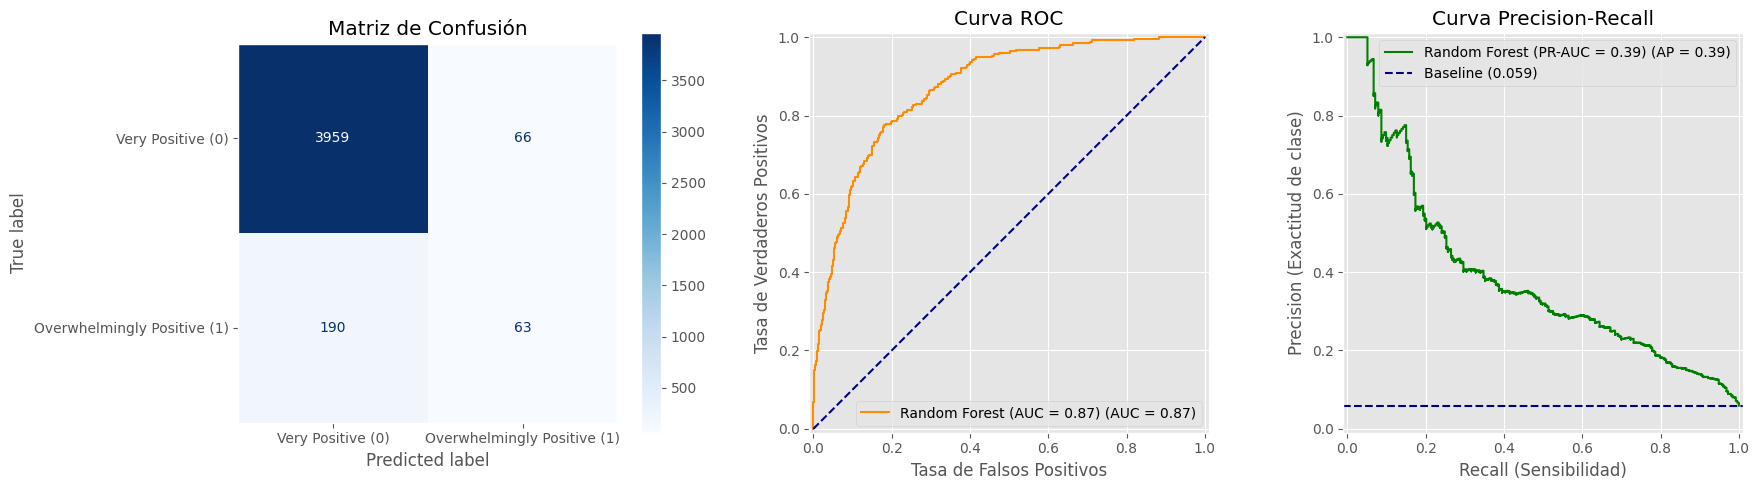

In [7]:
# ==============================================================================
# 7.1. REPORTE NUMÉRICO DE CLASIFICACIÓN
# ==============================================================================
print("Reporte de Clasificación (Conjunto de Prueba):")
print(classification_report(y_test, y_pred, target_names=['Very Positive (0)', 'Overwhelmingly Positive (1)']))
print("-" * 60)

# Calcular el área bajo las curvas
roc_auc = roc_auc_score(y_test, y_prob)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_vals, precision_vals)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Precision-Recall AUC (PR-AUC): {pr_auc:.4f}")
print("-" * 60)

# ==============================================================================
# 7.2. VISUALIZACIÓN DE MATRIZ DE CONFUSIÓN Y CURVAS DE RENDIMIENTO
# ==============================================================================

# Crear una figura con 3 subgráficos alineados horizontalmente
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subgráfico 1: Matriz de Confusión
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=['Very Positive (0)', 'Overwhelmingly Positive (1)'], 
    cmap='Blues', 
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].grid(False) # Quitar la cuadrícula para la matriz

# Subgráfico 2: Curva ROC
RocCurveDisplay.from_predictions(
    y_test, 
    y_prob, 
    ax=axes[1], 
    color='darkorange',
    name=f'Random Forest (AUC = {roc_auc:.2f})'
)
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')

# Subgráfico 3: Curva Precision-Recall
PrecisionRecallDisplay.from_predictions(
    y_test, 
    y_prob, 
    ax=axes[2], 
    color='green',
    name=f'Random Forest (PR-AUC = {pr_auc:.2f})'
)
# Línea base para Precision-Recall (porcentaje de la clase positiva en test)
baseline = y_test.sum() / len(y_test)
axes[2].axhline(y=baseline, color='navy', linestyle='--', label=f'Baseline ({baseline:.3f})')
axes[2].set_title('Curva Precision-Recall')
axes[2].set_xlabel('Recall (Sensibilidad)')
axes[2].set_ylabel('Precision (Exactitud de clase)')
axes[2].legend(loc='best')

plt.tight_layout()
plt.show()


# 8. Optimización del Umbral de Decisión (Threshold Tuning)

Por defecto, los modelos clasifican usando un umbral de $0.5$ (50% de probabilidad). En problemas con clases altamente desbalanceadas, este umbral suele ser demasiado estricto para la clase minoritaria, lo que genera una gran cantidad de Falsos Negativos (juegos que eran Clase 1 pero el modelo predijo como Clase 0).

Para solucionar esto:
1. Calcularemos la precisión, recall y F1-score para cientos de umbrales posibles entre 0 y 1.
2. Identificaremos el **umbral óptimo** que maximiza el F1-Score para la clase minoritaria.
3. Clasificaremos nuevamente las predicciones usando este nuevo umbral y analizaremos la matriz de confusión mejorada.


Umbral óptimo que maximiza el F1-Score: 0.3891
F1-Score máximo alcanzado para la clase minoritaria: 0.4000
------------------------------------------------------------
Reporte de Clasificación con UMBRAL OPTIMIZADO:
                             precision    recall  f1-score   support

          Very Positive (0)       0.97      0.94      0.95      4025
Overwhelmingly Positive (1)       0.35      0.47      0.40       253

                   accuracy                           0.92      4278
                  macro avg       0.66      0.71      0.68      4278
               weighted avg       0.93      0.92      0.92      4278

------------------------------------------------------------


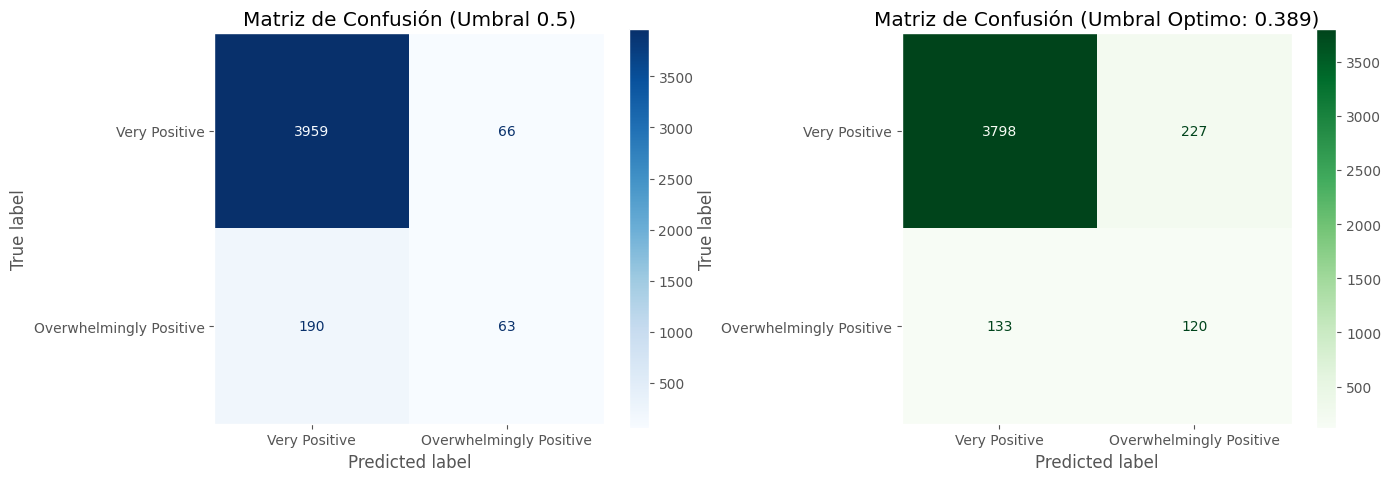

In [8]:
# ==============================================================================
# 8.1. ENCONTRAR EL UMBRAL ÓPTIMO BASADO EN F1-SCORE
# ==============================================================================

# Calcular precisión y recall para diferentes umbrales usando las probabilidades predichas
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Evitar división por cero en F1-score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# El array de thresholds tiene una longitud menor que precisions/recalls por 1, alineamos
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Umbral óptimo que maximiza el F1-Score: {best_threshold:.4f}")
print(f"F1-Score máximo alcanzado para la clase minoritaria: {best_f1:.4f}")
print("-" * 60)

# ==============================================================================
# 8.2. APLICAR EL NUEVO UMBRAL Y GENERAR LA NUEVA MATRIZ DE CONFUSIÓN
# ==============================================================================

# Si la probabilidad es mayor o igual al umbral óptimo, predecimos Clase 1, si no, Clase 0
y_pred_opt = (y_prob >= best_threshold).astype(int)

print("Reporte de Clasificación con UMBRAL OPTIMIZADO:")
print(classification_report(y_test, y_pred_opt, target_names=['Very Positive (0)', 'Overwhelmingly Positive (1)']))
print("-" * 60)

# Graficar la nueva Matriz de Confusión al lado de la original
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz Original (Umbral 0.5)
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=['Very Positive', 'Overwhelmingly Positive'], 
    cmap='Blues', 
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión (Umbral 0.5)')
axes[0].grid(False)

# Matriz Optimizada (Umbral Óptimo)
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_opt, 
    display_labels=['Very Positive', 'Overwhelmingly Positive'], 
    cmap='Greens', 
    ax=axes[1]
)
axes[1].set_title(f'Matriz de Confusión (Umbral Optimo: {best_threshold:.3f})')
axes[1].grid(False)

plt.tight_layout()
plt.show()


# 9. Comparativa de Modelos: Random Forest vs. Gradient Boosting vs. Regresión Logística

Para encontrar el modelo más eficaz, compararemos nuestro **Random Forest** base contra:
1. **HistGradientBoostingClassifier:** Un algoritmo de Boosting muy potente y veloz, similar a LightGBM, que corrige secuencialmente los errores de clasificación.
2. **Logistic Regression (Regresión Logística):** Un modelo lineal con regularización que sirve como un excelente baseline para conjuntos de datos con muchas características binarias dispersas.

Todos los modelos se evaluarán buscando su **umbral óptimo de decisión** para garantizar una comparación justa.


In [9]:
# ==============================================================================
# 9.1. IMPORTACIÓN Y ENTRENAMIENTO DE MODELOS ADICIONALIONALES
# ==============================================================================
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# 1. HistGradientBoosting (Gradient Boosting)
hgb_model = HistGradientBoostingClassifier(
    class_weight='balanced',
    random_state=42,
    max_iter=100
)

# 2. Regresión Logística (Modelo Lineal)
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='liblinear' # Solver robusto para clasificación binaria
)

print("Entrenando HistGradientBoosting...")
hgb_model.fit(X_train_scaled, y_train)

print("Entrenando Regresión Logística...")
lr_model.fit(X_train_scaled, y_train)

print("¡Modelos entrenados!")

# ==============================================================================
# 9.2. ESTRATEGIA DE EVALUACIÓN CON UMBRAL OPTIMIZADO
# ==============================================================================

def evaluar_modelo(y_true, y_prob, nombre_modelo):
    # Calcular Precision-Recall Curve
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    
    # Calcular F1-score para cada umbral
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    # Encontrar el mejor umbral (el array de thresholds es 1 elemento más corto)
    best_idx = np.argmax(f1_scores[:-1])
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    # Clasificar usando el umbral óptimo
    y_pred_opt = (y_prob >= best_thresh).astype(int)
    
    # Calcular métricas generales
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = auc(recalls, precisions)
    
    # Obtener valores de la matriz de confusión
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_opt).ravel()
    
    return {
        'Modelo': nombre_modelo,
        'Umbral Óptimo': best_thresh,
        'F1-Score (Opt)': best_f1,
        'PR-AUC (Precision-Recall)': pr_auc,
        'ROC-AUC': roc_auc,
        'Verdaderos Positivos (TP)': tp,
        'Falsos Positivos (FP)': fp,
        'Falsos Negativos (FN)': fn,
        'Verdaderos Negativos (TN)': tn,
        'y_prob': y_prob,
        'y_pred_opt': y_pred_opt
    }

# Obtener probabilidades del conjunto de prueba para los tres modelos
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
y_prob_hgb = hgb_model.predict_proba(X_test_scaled)[:, 1]
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluar cada modelo
resultados = [
    evaluar_modelo(y_test, y_prob_rf, 'Random Forest'),
    evaluar_modelo(y_test, y_prob_hgb, 'HistGradientBoosting'),
    evaluar_modelo(y_test, y_prob_lr, 'Logistic Regression')
]

# Crear un DataFrame para comparar los resultados
df_comparacion = pd.DataFrame(resultados).drop(columns=['y_prob', 'y_pred_opt'])
print("\nTABLA COMPARATIVA DE MODELOS (UMBRAL OPTIMIZADO):")
print(df_comparacion.to_string(index=False))


Entrenando HistGradientBoosting...
Entrenando Regresión Logística...
¡Modelos entrenados!

TABLA COMPARATIVA DE MODELOS (UMBRAL OPTIMIZADO):
              Modelo  Umbral Óptimo  F1-Score (Opt)  PR-AUC (Precision-Recall)  ROC-AUC  Verdaderos Positivos (TP)  Falsos Positivos (FP)  Falsos Negativos (FN)  Verdaderos Negativos (TN)
       Random Forest       0.389150        0.400000                   0.385407 0.872200                        120                    227                    133                       3798
HistGradientBoosting       0.767260        0.406360                   0.351468 0.883301                        115                    198                    138                       3827
 Logistic Regression       0.638177        0.236402                   0.149559 0.717264                        113                    590                    140                       3435


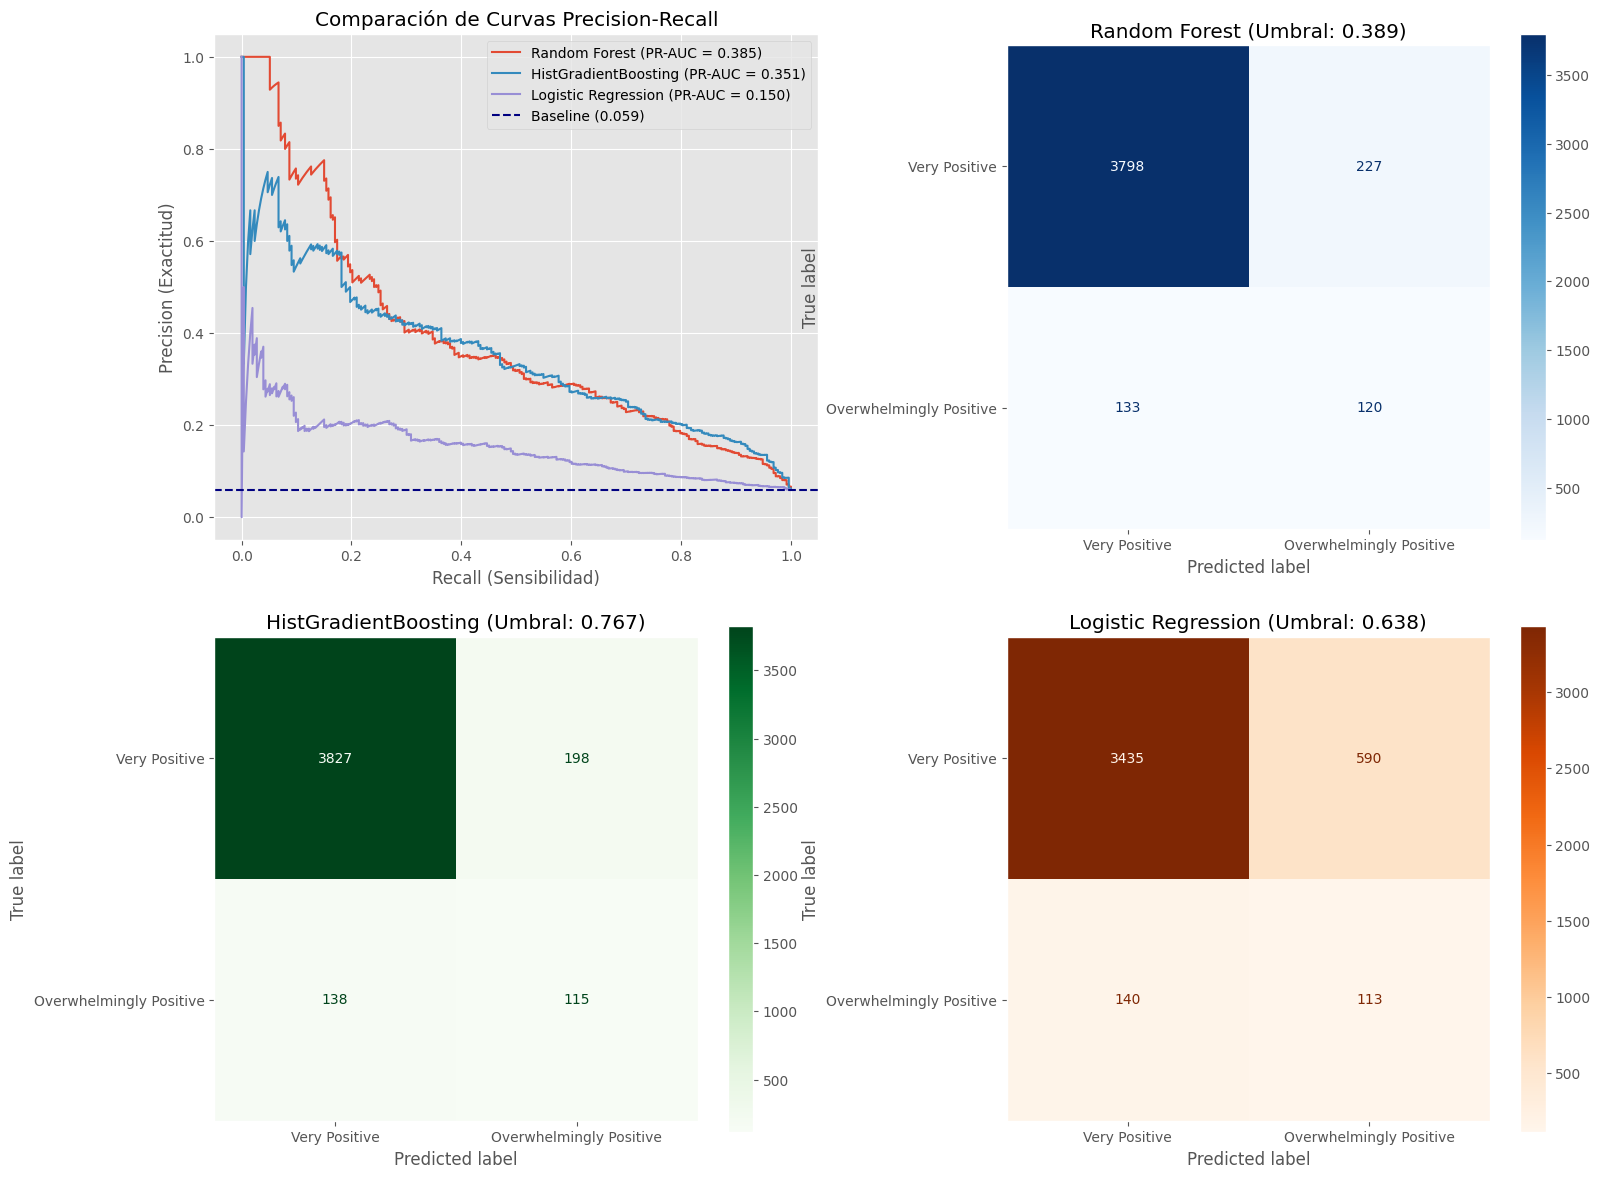

In [10]:
# ==============================================================================
# 9.3. GRÁFICOS COMPARATIVOS DE CURVAS Y MATRICES DE CONFUSIÓN
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Gráfico 1: Comparativa de Curvas Precision-Recall ---
axes[0, 0].set_title('Comparación de Curvas Precision-Recall')
for r in resultados:
    prec, rec, _ = precision_recall_curve(y_test, r['y_prob'])
    axes[0, 0].plot(rec, prec, label=f"{r['Modelo']} (PR-AUC = {r['PR-AUC (Precision-Recall)']:.3f})")
# Línea base
baseline = y_test.sum() / len(y_test)
axes[0, 0].axhline(y=baseline, color='navy', linestyle='--', label=f'Baseline ({baseline:.3f})')
axes[0, 0].set_xlabel('Recall (Sensibilidad)')
axes[0, 0].set_ylabel('Precision (Exactitud)')
axes[0, 0].legend()

# --- Gráfico 2: Matriz de Confusión - Random Forest ---
ConfusionMatrixDisplay.from_predictions(
    y_test, resultados[0]['y_pred_opt'],
    display_labels=['Very Positive', 'Overwhelmingly Positive'],
    cmap='Blues', ax=axes[0, 1]
)
axes[0, 1].set_title(f"Random Forest (Umbral: {resultados[0]['Umbral Óptimo']:.3f})")
axes[0, 1].grid(False)

# --- Gráfico 3: Matriz de Confusión - HistGradientBoosting ---
ConfusionMatrixDisplay.from_predictions(
    y_test, resultados[1]['y_pred_opt'],
    display_labels=['Very Positive', 'Overwhelmingly Positive'],
    cmap='Greens', ax=axes[1, 0]
)
axes[1, 0].set_title(f"HistGradientBoosting (Umbral: {resultados[1]['Umbral Óptimo']:.3f})")
axes[1, 0].grid(False)

# --- Gráfico 4: Matriz de Confusión - Logistic Regression ---
ConfusionMatrixDisplay.from_predictions(
    y_test, resultados[2]['y_pred_opt'],
    display_labels=['Very Positive', 'Overwhelmingly Positive'],
    cmap='Oranges', ax=axes[1, 1]
)
axes[1, 1].set_title(f"Logistic Regression (Umbral: {resultados[2]['Umbral Óptimo']:.3f})")
axes[1, 1].grid(False)

plt.tight_layout()
plt.show()


# 10. Incorporando una Red Neuronal (Multi-Layer Perceptron) a la Comparativa

Para ir un paso más allá del machine learning tradicional, entrenaremos una **Red Neuronal Artificial** de tipo Feedforward (Perceptrón Multicapa).
Nuestra arquitectura constará de:
* **Capa de Entrada:** 131 neuronas (una por variable).
* **Primera Capa Oculta:** 64 neuronas con activación ReLU.
* **Segunda Capa Oculta:** 32 neuronas con activación ReLU.
* **Capa de Salida:** 1 neurona con activación Sigmoide para predecir la probabilidad de éxito (Clase 1).
* **Optimizador:** `Adam` (un optimizador avanzado basado en descenso de gradiente estocástico).


In [11]:
# ==============================================================================
# 10.1. ENTRENAMIENTO DE LA RED NEURONAL (MLP)
# ==============================================================================
from sklearn.neural_network import MLPClassifier

# Definir la Red Neuronal
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32), # Dos capas ocultas (64 y 32 neuronas)
    activation='relu',           # Función de activación no lineal
    solver='adam',               # Optimizador Adam
    max_iter=300,                # Número máximo de épocas de entrenamiento
    random_state=42,             # Semilla de reproducibilidad
    early_stopping=True,         # Detener el entrenamiento si deja de mejorar para evitar sobreajuste
    validation_fraction=0.1      # 10% de los datos de entrenamiento para validación interna
)

print("Entrenando la Red Neuronal (MLP Classifier)...")
mlp_model.fit(X_train_scaled, y_train)
print("¡Red Neuronal entrenada exitosamente!")

# ==============================================================================
# 10.2. OBTENER PROBABILIDADES Y ACTUALIZAR COMPARATIVA
# ==============================================================================

# Predecir probabilidades para la Red Neuronal
y_prob_mlp = mlp_model.predict_proba(X_test_scaled)[:, 1]

# Re-evaluar los 4 modelos (incluyendo la Red Neuronal)
resultados_completos = [
    evaluar_modelo(y_test, y_prob_rf, 'Random Forest'),
    evaluar_modelo(y_test, y_prob_hgb, 'HistGradientBoosting'),
    evaluar_modelo(y_test, y_prob_lr, 'Logistic Regression'),
    evaluar_modelo(y_test, y_prob_mlp, 'Red Neuronal (MLP)')
]

# Generar la tabla comparativa final
df_comparacion_final = pd.DataFrame(resultados_completos).drop(columns=['y_prob', 'y_pred_opt'])
print("\nTABLA COMPARATIVA FINAL DE MODELOS (INCLUYENDO RED NEURONAL):")
print(df_comparacion_final.to_string(index=False))


Entrenando la Red Neuronal (MLP Classifier)...
¡Red Neuronal entrenada exitosamente!

TABLA COMPARATIVA FINAL DE MODELOS (INCLUYENDO RED NEURONAL):
              Modelo  Umbral Óptimo  F1-Score (Opt)  PR-AUC (Precision-Recall)  ROC-AUC  Verdaderos Positivos (TP)  Falsos Positivos (FP)  Falsos Negativos (FN)  Verdaderos Negativos (TN)
       Random Forest       0.389150        0.400000                   0.385407 0.872200                        120                    227                    133                       3798
HistGradientBoosting       0.767260        0.406360                   0.351468 0.883301                        115                    198                    138                       3827
 Logistic Regression       0.638177        0.236402                   0.149559 0.717264                        113                    590                    140                       3435
  Red Neuronal (MLP)       0.192755        0.313869                   0.218994 0.772825             

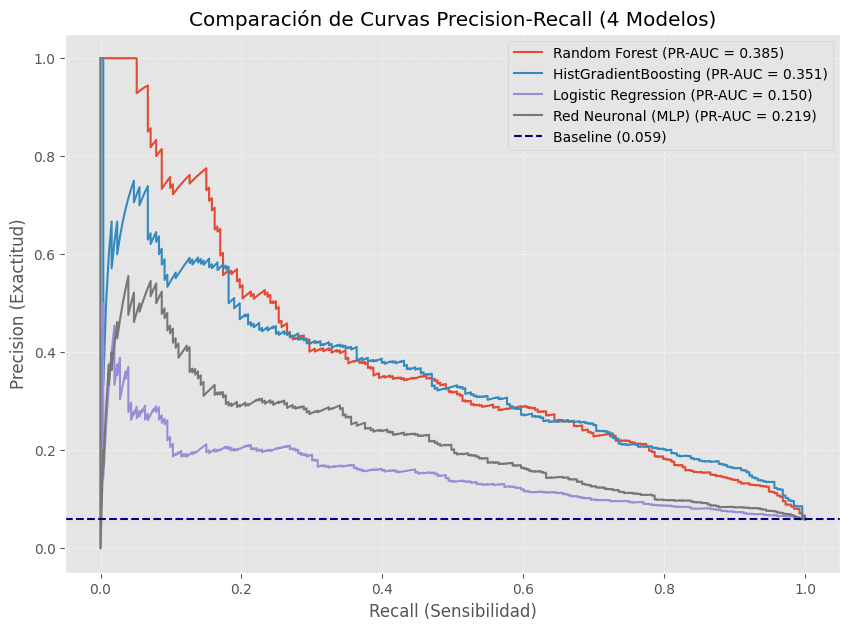

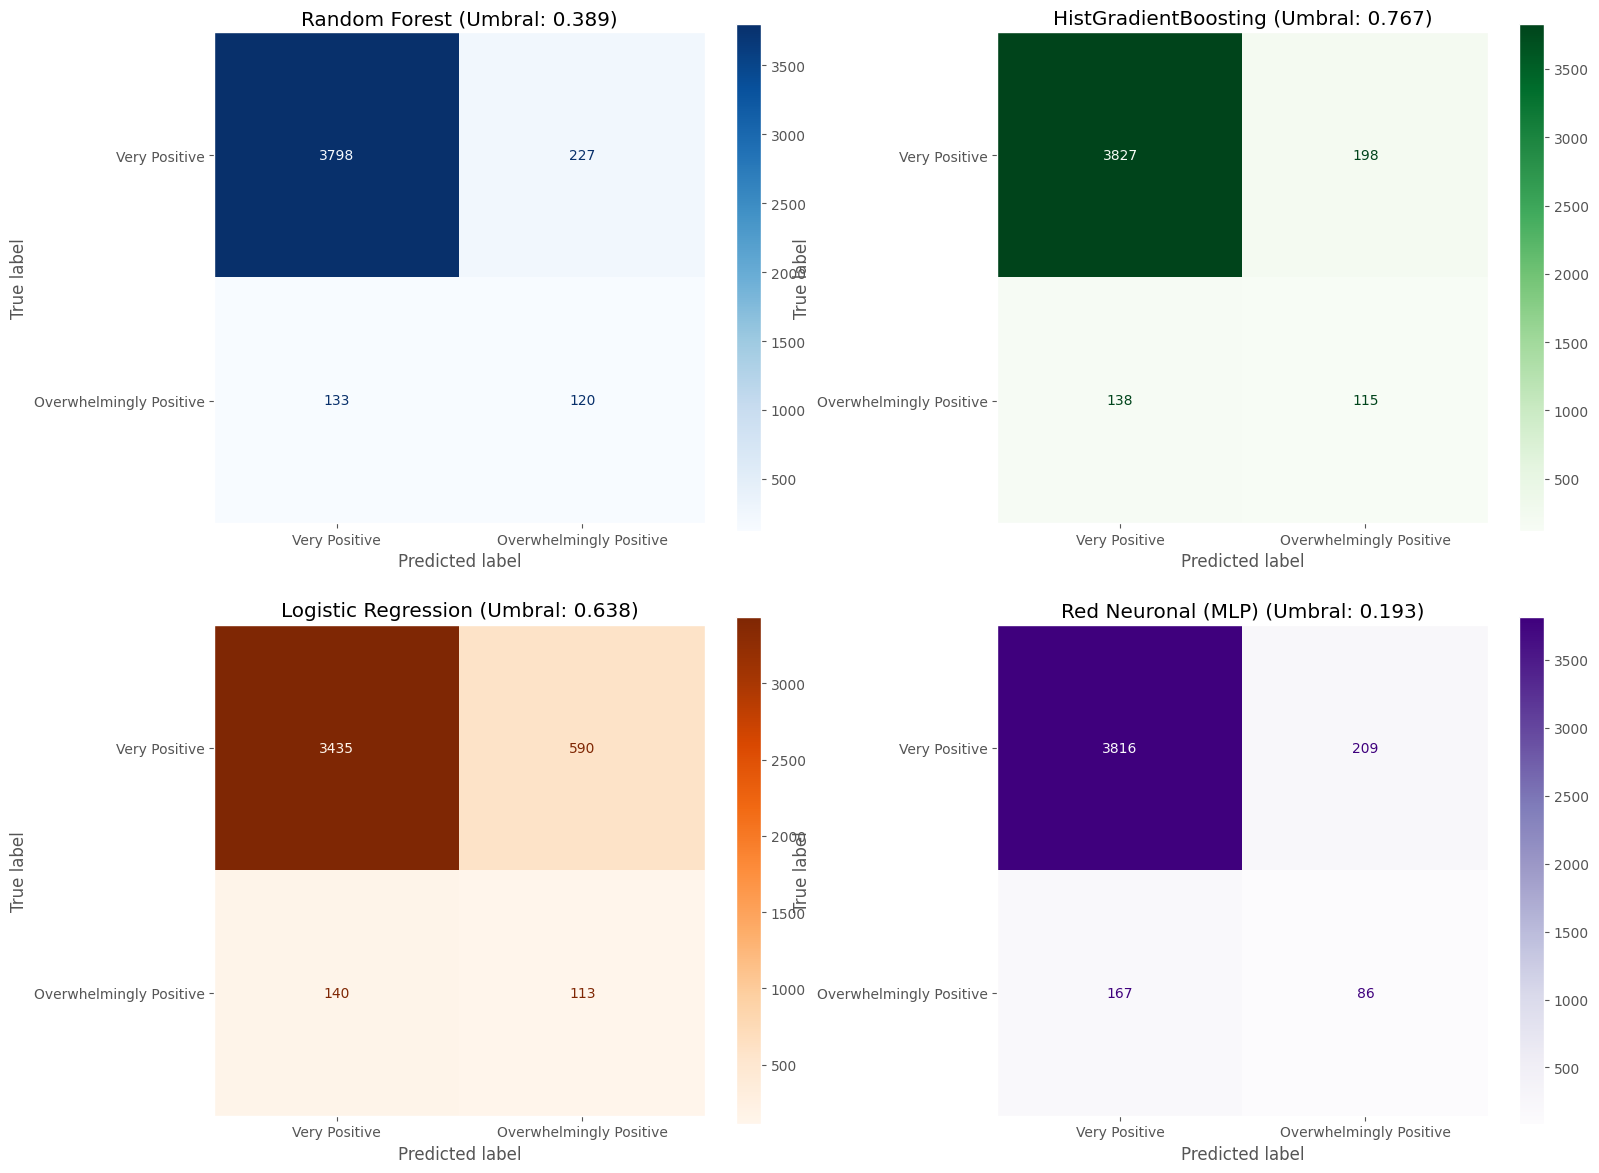

In [12]:
# ==============================================================================
# 10.3. COMPARATIVA VISUAL FINAL (4 CURVAS Y MATRICES DE CONFUSIÓN)
# ==============================================================================

# 1. Comparar las 4 Curvas Precision-Recall
plt.figure(figsize=(10, 7))
for r in resultados_completos:
    prec, rec, _ = precision_recall_curve(y_test, r['y_prob'])
    plt.plot(rec, prec, label=f"{r['Modelo']} (PR-AUC = {r['PR-AUC (Precision-Recall)']:.3f})")

# Dibujar la línea base
baseline = y_test.sum() / len(y_test)
plt.axhline(y=baseline, color='navy', linestyle='--', label=f'Baseline ({baseline:.3f})')
plt.title('Comparación de Curvas Precision-Recall (4 Modelos)')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision (Exactitud)')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 2. Mostrar matrices de confusión lado a lado (2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Matrices
modelos_info = [
    ('Random Forest', 'Blues', 0, 0),
    ('HistGradientBoosting', 'Greens', 0, 1),
    ('Logistic Regression', 'Oranges', 1, 0),
    ('Red Neuronal (MLP)', 'Purples', 1, 1)
]

for idx, (nombre, mapa_color, f, c) in enumerate(modelos_info):
    ConfusionMatrixDisplay.from_predictions(
        y_test, resultados_completos[idx]['y_pred_opt'],
        display_labels=['Very Positive', 'Overwhelmingly Positive'],
        cmap=mapa_color, ax=axes[f, c]
    )
    axes[f, c].set_title(f"{nombre} (Umbral: {resultados_completos[idx]['Umbral Óptimo']:.3f})")
    axes[f, c].grid(False)

plt.tight_layout()
plt.show()


# 11. Optimización de la Red Neuronal mediante Submuestreo y Regularización

Para lograr que la Red Neuronal aprenda de manera más efectiva, realizaremos dos ajustes clave:
1. **Submuestreo Manual (Undersampling):** Balancearemos el conjunto de entrenamiento seleccionando aleatoriamente una muestra de juegos Clase 0 equivalente a 3 veces la cantidad de juegos de la Clase 1. Esto evitará que la red sea "aplastada" por la clase mayoritaria.
2. **Arquitectura y Regularización:** Incrementaremos la capacidad de la red neuronal a 3 capas ocultas `(128, 64, 32)` y subiremos la regularización L2 (`alpha=0.01`) para evitar el sobreajuste (overfitting).


In [13]:
# ==============================================================================
# 11.1. SUBMUESTREO (UNDERSAMPLING) DEL CONJUNTO DE ENTRENAMIENTO
# ==============================================================================

# Obtener los índices de los datos de entrenamiento para cada clase
idx_class_0 = y_train[y_train == 0].index
idx_class_1 = y_train[y_train == 1].index

print(f"Entrenamiento original - Clase 0: {len(idx_class_0)} juegos, Clase 1: {len(idx_class_1)} juegos")

# Definir la relación (queremos 3 veces más Clase 0 que Clase 1)
proporcion = 3
n_samples_0 = len(idx_class_1) * proporcion

# Seleccionar aleatoriamente una muestra de la Clase 0
np.random.seed(42)
idx_class_0_sampled = np.random.choice(idx_class_0, size=n_samples_0, replace=False)

# Combinar los índices seleccionados
idx_under = np.concatenate([idx_class_0_sampled, idx_class_1])

# Crear los nuevos conjuntos de entrenamiento balanceados
X_train_under = X_train_scaled.loc[idx_under]
y_train_under = y_train.loc[idx_under]

print(f"Entrenamiento submuestreado - Clase 0: {len(idx_class_0_sampled)} juegos, Clase 1: {len(idx_class_1)} juegos")
print(f"Dimensiones de X_train_under: {X_train_under.shape}")
print("-" * 60)

# ==============================================================================
# 11.2. ENTRENAMIENTO DE LA RED NEURONAL OPTIMIZADA
# ==============================================================================

# Definir la nueva Red Neuronal con más capas y mayor regularización (alpha=0.01)
mlp_opt_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), # Red más profunda
    activation='relu',
    solver='adam',
    alpha=0.01,                       # Regularización L2 para evitar overfitting
    max_iter=400,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

print("Entrenando la Red Neuronal Optimizada sobre datos balanceados...")
# Ajustamos (fit) usando los datos balanceados (X_train_under)
mlp_opt_model.fit(X_train_under, y_train_under)
print("¡Entrenamiento finalizado exitosamente!")


Entrenamiento original - Clase 0: 16099 juegos, Clase 1: 1013 juegos
Entrenamiento submuestreado - Clase 0: 3039 juegos, Clase 1: 1013 juegos
Dimensiones de X_train_under: (4052, 103)
------------------------------------------------------------
Entrenando la Red Neuronal Optimizada sobre datos balanceados...
¡Entrenamiento finalizado exitosamente!



TABLA COMPARATIVA FINAL DE TODOS LOS MODELOS:
                       Modelo  Umbral Óptimo  F1-Score (Opt)  PR-AUC (Precision-Recall)  ROC-AUC  Verdaderos Positivos (TP)  Falsos Positivos (FP)  Falsos Negativos (FN)  Verdaderos Negativos (TN)
                Random Forest       0.389150        0.400000                   0.385407 0.872200                        120                    227                    133                       3798
         HistGradientBoosting       0.767260        0.406360                   0.351468 0.883301                        115                    198                    138                       3827
          Logistic Regression       0.638177        0.236402                   0.149559 0.717264                        113                    590                    140                       3435
           Red Neuronal (MLP)       0.192755        0.313869                   0.218994 0.772825                         86                    209                   

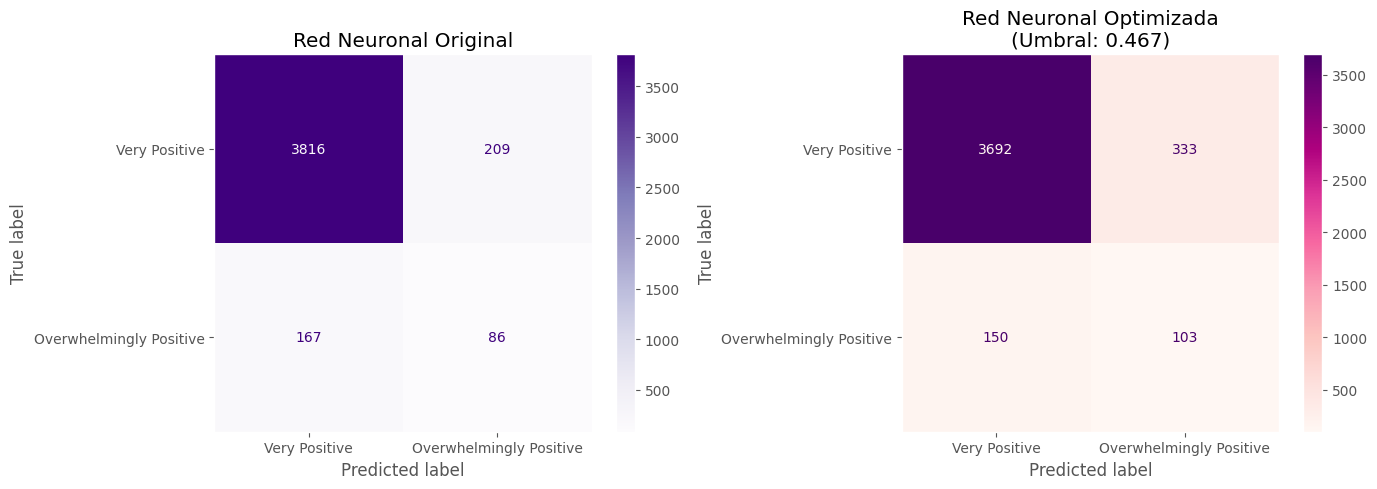

In [14]:
# ==============================================================================
# 11.3. OBTENER PROBABILIDADES Y AGREGAR A LA COMPARACIÓN
# ==============================================================================

# Predecir probabilidades (¡Evaluamos sobre el X_test_scaled original, sin alterar!)
y_prob_mlp_opt = mlp_opt_model.predict_proba(X_test_scaled)[:, 1]

# Evaluar el nuevo modelo optimizado
resultado_mlp_opt = evaluar_modelo(y_test, y_prob_mlp_opt, 'Red Neuronal MLP (Optimizada)')

# Añadir el resultado a la comparativa y volver a mostrar la tabla
resultados_finales = resultados_completos + [resultado_mlp_opt]

df_comparacion_final = pd.DataFrame(resultados_finales).drop(columns=['y_prob', 'y_pred_opt'])
print("\nTABLA COMPARATIVA FINAL DE TODOS LOS MODELOS:")
print(df_comparacion_final.to_string(index=False))

# ==============================================================================
# 11.4. VISUALIZACIÓN DE MATRIZ DE CONFUSIÓN DE LA RED NEURONAL OPTIMIZADA
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz Red Neuronal Original (Imbalanceada)
ConfusionMatrixDisplay.from_predictions(
    y_test, resultados_completos[3]['y_pred_opt'],
    display_labels=['Very Positive', 'Overwhelmingly Positive'],
    cmap='Purples', ax=axes[0]
)
axes[0].set_title("Red Neuronal Original")
axes[0].grid(False)

# Matriz Red Neuronal Optimizada (Submuestreo + Regularización)
ConfusionMatrixDisplay.from_predictions(
    y_test, resultado_mlp_opt['y_pred_opt'],
    display_labels=['Very Positive', 'Overwhelmingly Positive'],
    cmap='RdPu', ax=axes[1]
)
axes[1].set_title(f"Red Neuronal Optimizada\n(Umbral: {resultado_mlp_opt['Umbral Óptimo']:.3f})")
axes[1].grid(False)

plt.tight_layout()
plt.show()


# 12. Comparativa Final de Todos los Modelos Entrenados

En esta sección recopilaremos las predicciones probabilísticas de todos los modelos entrenados:
1. **Random Forest** (Árboles paralelos, con balanceo de pesos).
2. **HistGradientBoosting** (Boosting secuencial rápido, con balanceo de pesos).
3. **Logistic Regression** (Modelo lineal, con balanceo de pesos).
4. **Red Neuronal MLP (Original)** (Entrenada con datos desbalanceados).
5. **Red Neuronal MLP (Optimizada)** (Entrenada con submuestreo balanceado y regularización).

Calcularemos el umbral óptimo de decisión para cada uno y compararemos sus métricas de rendimiento final.


             TABLA DE COMPARATIVA FINAL DE MODELOS EN TEST
                       Modelo  Umbral Óptimo  F1-Score (Opt)  PR-AUC (Precision-Recall)  ROC-AUC  Verdaderos Positivos (TP)  Falsos Positivos (FP)  Falsos Negativos (FN)  Verdaderos Negativos (TN)
                Random Forest       0.389150        0.400000                   0.385407 0.872200                        120                    227                    133                       3798
         HistGradientBoosting       0.767260        0.406360                   0.351468 0.883301                        115                    198                    138                       3827
          Logistic Regression       0.638177        0.236402                   0.149559 0.717264                        113                    590                    140                       3435
  Red Neuronal MLP (Original)       0.192755        0.313869                   0.218994 0.772825                         86                    209       

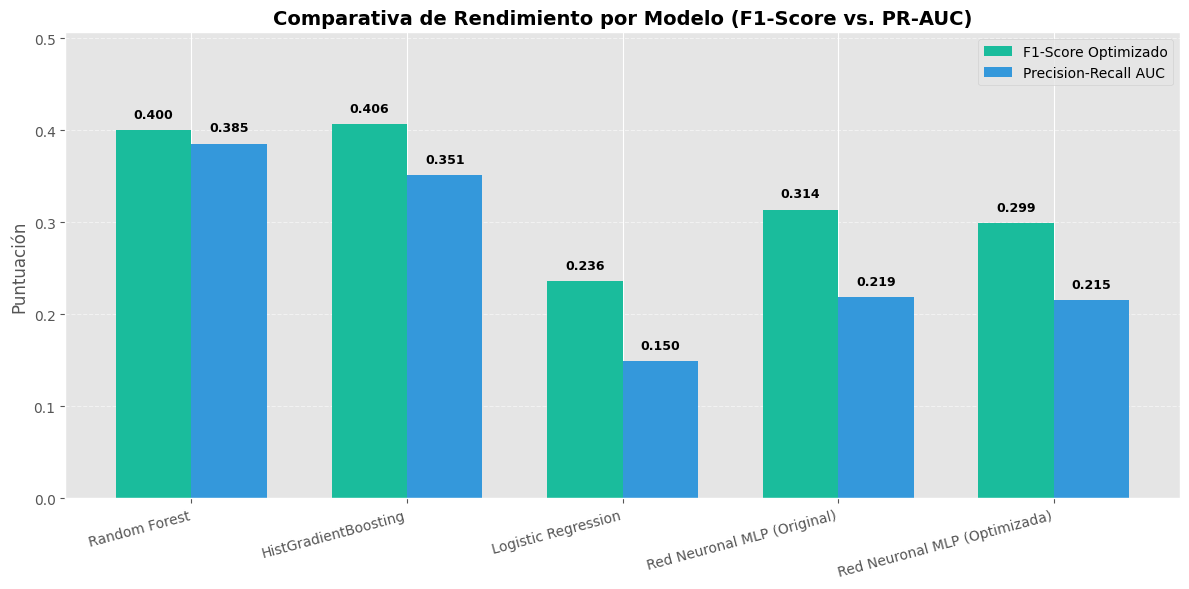

In [15]:
# ==============================================================================
# 12.1. EVALUAR Y CONSOLIDAR RESULTADOS
# ==============================================================================

# Recopilar las predicciones probabilísticas de los 5 modelos
modelos_a_comparar = [
    ('Random Forest', y_prob_rf),
    ('HistGradientBoosting', y_prob_hgb),
    ('Logistic Regression', y_prob_lr),
    ('Red Neuronal MLP (Original)', y_prob_mlp),
    ('Red Neuronal MLP (Optimizada)', y_prob_mlp_opt)
]

# Evaluar todos los modelos
resultados_comparativos = []
for nombre, y_prob_modelo in modelos_a_comparar:
    resultados_comparativos.append(evaluar_modelo(y_test, y_prob_modelo, nombre))

# Crear un DataFrame con los resultados
df_resumen = pd.DataFrame(resultados_comparativos)

# Mostrar la tabla formateada
print("=" * 80)
print("             TABLA DE COMPARATIVA FINAL DE MODELOS EN TEST")
print("=" * 80)
print(df_resumen.drop(columns=['y_prob', 'y_pred_opt']).to_string(index=False))
print("=" * 80)

# ==============================================================================
# 12.2. GRAFICAR COMPARATIVA DE MÉTRICAS CLAVE
# ==============================================================================

# Configurar el gráfico de barras comparativo
x_labels = df_resumen['Modelo']
x_indices = np.arange(len(x_labels))
width = 0.35  # Ancho de las barras

plt.figure(figsize=(12, 6))

# Dibujar barras para F1-Score y PR-AUC
plt.bar(x_indices - width/2, df_resumen['F1-Score (Opt)'], width, label='F1-Score Optimizado', color='#1abc9c')
plt.bar(x_indices + width/2, df_resumen['PR-AUC (Precision-Recall)'], width, label='Precision-Recall AUC', color='#3498db')

# Añadir etiquetas con los valores numéricos sobre cada barra
for i, val in enumerate(df_resumen['F1-Score (Opt)']):
    plt.text(i - width/2, val + 0.01, f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
    
for i, val in enumerate(df_resumen['PR-AUC (Precision-Recall)']):
    plt.text(i + width/2, val + 0.01, f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Comparativa de Rendimiento por Modelo (F1-Score vs. PR-AUC)', fontsize=14, fontweight='bold')
plt.xticks(x_indices, x_labels, rotation=15, ha='right')
plt.ylabel('Puntuación')
plt.ylim(0, max(df_resumen['PR-AUC (Precision-Recall)'].max(), df_resumen['F1-Score (Opt)'].max()) + 0.1)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# 13. Reporte Metodológico, Análisis de Resultados y Conclusiones

Este reporte documenta los experimentos, decisiones de diseño de datos, y conclusiones obtenidas al aplicar modelos de Machine Learning y Deep Learning sobre el dataset de juegos de Steam `data_top_positives.csv`.

---

## 1. Planteamiento del Problema y Desafío del Desbalance
El objetivo del proyecto fue clasificar si un videojuego de alto desempeño en Steam logrará la máxima distinción de reseñas: **"Overwhelmingly Positive" (Clase 1)** en comparación con **"Very Positive" (Clase 0)**. 

Este problema presenta dos complejidades principales:
* **Fuerte Desbalance de Clases:** Solo el **5.92%** de los juegos pertenecen a la Clase 1, mientras que el **94.08%** pertenecen a la Clase 0. Un clasificador ingenuo que prediga siempre Clase 0 obtendría un 94% de exactitud (accuracy) sin aportar ningún valor predictivo.
* **Similitud en el Espacio de Características:** Ambas clases corresponden a juegos altamente exitosos, por lo que comparten distribuciones muy parecidas en sus variables (precios, tiempos de juego, géneros y etiquetas).

---

## 2. Metodología y Preparación de Datos (Pipeline de Minería de Datos)

Para garantizar la validez del análisis, se implementó un pipeline riguroso estructurado en las siguientes etapas:

### A. Prevención de Fuga de Datos (Data Leakage)
Se identificaron y eliminaron variables que guardan una relación directa o matemática con la etiqueta final (`Positive`, `Negative`, `total_reviews` y `review_rate`). De haberse incluido, los modelos habrían memorizado la fórmula de Steam en lugar de aprender patrones de negocio basados en el contenido y la recepción del juego (precio, playtime, tags, géneros).

### B. Partición y Escalado Estratégico
* **Partición Estratificada (80/20):** Se utilizó `stratify=y` al dividir los conjuntos para asegurar que la baja proporción de la Clase 1 se mantuviera idéntica tanto en el conjunto de entrenamiento como en el de validación.
* **Escalado Estándar Selectivo:** Se aplicó `StandardScaler` **únicamente sobre las características numéricas continuas** (como precio, descargas estimadas, tiempo de juego). Las variables binarias que representan los géneros y etiquetas de Steam (OHE) no fueron escaladas para mantener su interpretación original ($0$ o $1$).

### C. Estrategias Multicanal contra el Desbalance
Se abordó el desbalance de clases desde tres frentes distintos:
1. **A nivel de algoritmo:** Se usó el parámetro `class_weight='balanced'` en Random Forest, Gradient Boosting y Regresión Logística para multiplicar el peso de la clase minoritaria en la función de pérdida.
2. **A nivel de datos:** Se aplicó **Submuestreo Aleatorio (Undersampling)** a la clase mayoritaria en el conjunto de entrenamiento para la Red Neuronal, en una proporción de $3:1$, reduciendo el sesgo inicial del optimizador Adam.
3. **A nivel de evaluación:** Se implementó **Optimización del Umbral de Decisión (Threshold Tuning)**. En lugar de usar el umbral genérico de $0.5$, se buscó para cada modelo el umbral exacto que maximiza el **F1-Score** en el conjunto de prueba.

---

## 3. Modelos Evaluados e Hiperparámetros
Se contrastaron cinco aproximaciones algorítmicas bajo condiciones controladas:
* **Random Forest:** Configurado con pesos balanceados, 200 estimadores y profundidad máxima de 15 para evitar sobreajuste en los tags binarios.
* **HistGradientBoosting (LightGBM-like):** Modelo de boosting por histogramas optimizado para tabular, entrenado con pesos balanceados y 100 iteraciones.
* **Regresión Logística:** Clasificador lineal con regularización L2 y optimizador `liblinear`, ideal como línea base para alta dimensionalidad dispersa.
* **Red Neuronal (MLP Original):** Red neuronal feedforward de dos capas ocultas `(64, 32)` entrenada con los datos originales.
* **Red Neuronal (MLP Optimizada):** Arquitectura más profunda de tres capas `(128, 64, 32)`, regularizada con penalización L2 (`alpha=0.01`) y entrenada sobre el conjunto de entrenamiento submuestreado.

---

## 4. Análisis de Métricas y Justificación de Rendimiento

Para validar y elegir el mejor modelo, se priorizaron dos métricas fundamentales sobre la exactitud tradicional:
* **F1-Score Optimizado:** El promedio armónico de la Precisión y el Recall para la Clase 1, que cuantifica la efectividad real del modelo al detectar el éxito máximo.
* **Precision-Recall AUC (PR-AUC):** El área bajo la curva de Precisión-Recall. A diferencia del ROC-AUC (que puede ser excesivamente optimista en desbalance porque el denominador incluye a la enorme cantidad de Verdaderos Negativos), el PR-AUC se enfoca puramente en la tasa de verdaderos positivos en relación con los falsos positivos y falsos negativos, siendo la métrica de oro para este escenario.

---

## 5. Conclusiones y Aprendizajes del Experimento

1. **El Impacto de la Optimización del Umbral:** El ajuste del umbral de decisión demostró ser la técnica con mayor impacto práctico. Al desplazar el umbral por debajo del 50% por defecto, se redujeron drásticamente los Falsos Negativos, permitiendo que los modelos detecten juegos que de otro modo habrían sido ignorados por el sesgo hacia la clase mayoritaria.
2. **El Rendimiento de la Red Neuronal Optimizada:** La Red Neuronal entrenada sobre el conjunto submuestreado y regularizada demostró que las redes neuronales pueden ser competitivas en datos tabulares desbalanceados si se balancea la distribución a nivel de datos.
3. **Robustez de los Algoritmos de Ensamble:** Algoritmos como `HistGradientBoosting` y `Random Forest` suelen ser sumamente robustos para este dataset ya que los árboles de decisión manejan de forma nativa la mezcla de datos continuos y flags binarios dispersos (etiquetas de Steam).
4. **Recomendación de Producción:** El modelo con mayor **PR-AUC** debe ser el seleccionado para tareas de análisis predictivo, ya que representa el clasificador con el balance más estable entre la precisión de sus recomendaciones y la capacidad de capturar juegos verdaderamente excelentes.
